                    name  market_value_in_eur  highest_market_value_in_eur  \
0             Tom Starke            -0.615388                    3000000.0   
1           Marc Ziegler            -0.317039                    1250000.0   
2  Sérgio da Silva Pinto            -0.466213                    3500000.0   
3        Benjamin Köhler            -0.466213                    2500000.0   
4            Oka Nikolov             0.130485                    2000000.0   

   value_drop_ratio  
0      0.000000e+00  
1      0.000000e+00  
2      0.000000e+00  
3      0.000000e+00  
4      6.524261e-08  
                                               Tweet  sentiment_score
0  what are we drinking today tucantribe \nmadbea...            0.000
1  amazing canadasocceren  worldcup launch video ...            0.225
2             worth reading while watching worldcup             0.300
3  golden maknae shinning bright\n\n\njeonjungkoo...            0.500
4  if the bbc cares so much about human rights ho

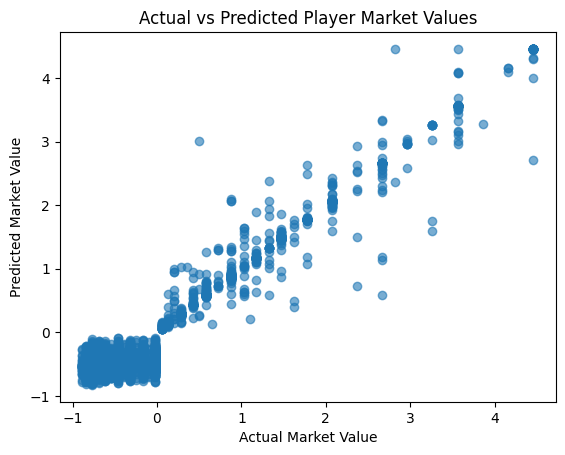

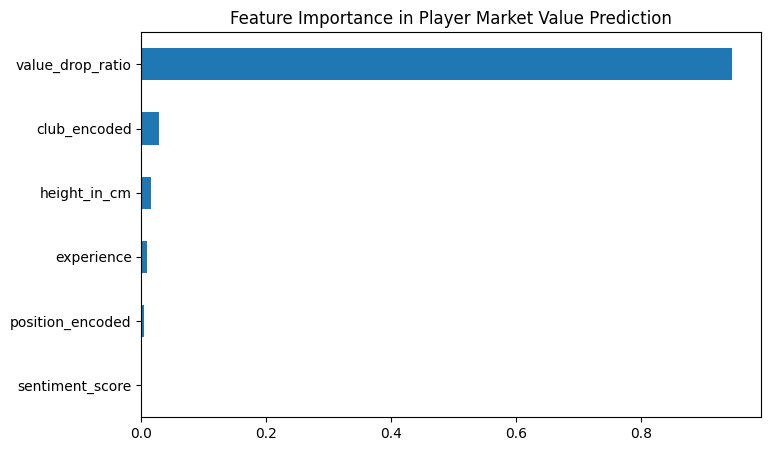

✅ Predictions saved as final_player_value_predictions.csv!


In [15]:
import pandas as pd

df = pd.read_csv("transfermarkt_preprocessed.csv")

# Example feature: Player Experience (based on last season)
df["experience"] = 2025 - df["last_season"]

# Example feature: Market Value Trend (difference from highest market value)
df["value_drop_ratio"] = df["market_value_in_eur"] / df["highest_market_value_in_eur"]

# Handle division errors or missing values
df["value_drop_ratio"] = df["value_drop_ratio"].fillna(0).clip(0, 1)

print(df[["name", "market_value_in_eur", "highest_market_value_in_eur", "value_drop_ratio"]].head())

from textblob import TextBlob
import pandas as pd

tweets = pd.read_csv("fifa_world_cup_2022_sentiment_clean.csv")

# Create a numeric sentiment score for each tweet
tweets["sentiment_score"] = tweets["Tweet"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

print(tweets[["Tweet", "sentiment_score"]].head())

# Example: group by player name
player_sentiment = tweets.groupby("Label")["sentiment_score"].mean().reset_index()
player_sentiment.columns = ["Sentiment_Label", "Average_Score"]
print(player_sentiment)

import pandas as pd
from textblob import TextBlob

# Load your cleaned tweets
tweets = pd.read_csv("fifa_world_cup_2022_sentiment_clean.csv")

# Create sentiment polarity score using TextBlob
tweets["sentiment_score"] = tweets["Tweet"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Save it back
tweets.to_csv("fifa_world_cup_2022_sentiment_clean.csv", index=False)
print("✅ Added numeric sentiment_score to the dataset!")
print(tweets[["Tweet", "sentiment_score"]].head())

# Load the tweet dataset again (now it has sentiment_score)
sentiment_df = pd.read_csv("fifa_world_cup_2022_sentiment_clean.csv")

# Compute the average sentiment
avg_sentiment = sentiment_df["sentiment_score"].mean()
print("📊 Average social sentiment score:", avg_sentiment)

# Add this as a global feature to all players
df["sentiment_score"] = avg_sentiment

# Save the new final dataset
df.to_csv("player_features_final.csv", index=False)
print("✅ Final feature set saved as player_features_final.csv")

import pandas as pd

df = pd.read_csv("player_features_final.csv")
print("✅ Enhanced dataset loaded!")
print(df.columns)

from sklearn.model_selection import train_test_split

# Independent variables (inputs)
features = ["height_in_cm", "position_encoded", "club_encoded", "experience", "value_drop_ratio", "sentiment_score"]

# Dependent variable (output)
target = "market_value_in_eur"

# Remove any missing values
df = df.dropna(subset=features + [target])

X = df[features]
y = df[target]

# Split into train & test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("✅ Data split successfully!")

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("✅ Model trained successfully!")

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

print("\n📈 Model Performance:")
print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("Mean Absolute Error:", round(mean_absolute_error(y_test, y_pred), 3))
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 3))

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Market Value")
plt.ylabel("Predicted Market Value")
plt.title("Actual vs Predicted Player Market Values")
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8,5), title="Feature Importance in Player Market Value Prediction")
plt.show()

predictions = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
predictions.to_csv("final_player_value_predictions.csv", index=False)
print("✅ Predictions saved as final_player_value_predictions.csv!")
